In [1]:
#%%
%load_ext autoreload
%autoreload 2

#### How much do the sets of individuals that models predict as 0 overlap?

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches

import scipy as sp


#load the dataset
import folktexts
from folktexts.acs.acs_tasks import ACSTaskMetadata
from folktexts.acs.acs_dataset import ACSDataset

from pathlib import Path
from folktexts.analysis.setup import ACS_TASKS, LLM_MODELS, baselines
from folktexts.analysis.analysis import expected_agreement
from folktexts.analysis.utils import key_to_model, get_metric, get_predictions, prettify_model_name, load_baselines, is_instruction_tuned, truncate
from folktexts.llm_utils import get_model_size_B

plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR/'overview_results_by_prompt_style.csv'

#### Load Dataframe

In [3]:
df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
prompt_style = 'bullet'
prompt_connector = 'is' #':','=', 'is'
df = df[(df['num_shots'] == 0) & (df['prompt_style'] == 'bullet') & (df['prompt_connector'] == 'is')]
df.head()

,task,model,is_inst,bench_hash,num_shots,prompt_style,prompt_connector,eval_results_path,predictions_path
0,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,862320328,0,bullet,is,results/0-bullet-is/model-meta-llama--Meta-Lla...,results/0-bullet-is/model-meta-llama--Meta-Lla...
1,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1231502606,0,bullet,is,results/0-bullet-is/model-allenai--OLMo-2-1124...,results/0-bullet-is/model-allenai--OLMo-2-1124...
2,ACSIncome,google--gemma-2-27b,0,3535356034,0,bullet,is,results/0-bullet-is/model-google--gemma-2-27b/...,results/0-bullet-is/model-google--gemma-2-27b/...
3,ACSIncome,google--gemma-2-27b-it,1,1373954821,0,bullet,is,results/0-bullet-is/model-google--gemma-2-27b-...,results/0-bullet-is/model-google--gemma-2-27b-...
4,ACSIncome,meta-llama--Meta-Llama-3-70B,0,730840778,0,bullet,is,results/0-bullet-is/model-meta-llama--Meta-Lla...,results/0-bullet-is/model-meta-llama--Meta-Lla...


In [4]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=ACS_TASKS)

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/baselines/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSEmployment'.


- LR: Load predictions from 'results/baselines/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSEmployment'.
Loading baselines for ACSTravelTime.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSTravelTime'.
- LR: Load predictions from 'results/baselines/LR_task-ACSTravelTime'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSTravelTime'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSTravelTime'.
Loading baselines for ACSPublicCoverage.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSPublicCoverage'.
- LR: Load predictions from 'results/baselines/LR_task-ACSPublicCoverage'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSPublicCoverage'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSPublicCoverage'.


In [5]:
baseline_predictions = {task:baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in ACS_TASKS}
baseline_predictions['ACSIncome'].head()    

,Constant_task-ACSIncome,LR_task-ACSIncome,GBM_task-ACSIncome,XGBoost_task-ACSIncome
238351,0,0,0,0
2995677,0,0,0,0
2360043,0,0,1,1
1924596,0,0,0,0
2803585,0,0,0,0


In [6]:
# load predictions and measured accuracies
predictions = {}
accuracies = {}
fn_rates = {}
for task in ACS_TASKS:
    task_df = df[(df['task'] == task)]

    # available models
    models = task_df['model'].unique().tolist()
    models.sort(key=lambda m: get_model_size_B(m) + int(is_instruction_tuned(m)))
    predictions_per_task = []
    accuracies[task] = {}
    fn_rates[task] = {}
    for m in models: 
        data_m = task_df[task_df['model'] == m]
        assert data_m.shape[0] == 1, f"Expected 1 row for model {m} but found {data_m.shape[0]}"
        accuracies[task][m] = get_metric(data_m.iloc[0]['eval_results_path'], metric="accuracy")
        fn_rates[task][m] = get_metric(data_m.iloc[0]['eval_results_path'], metric="fnr")
        predictions_per_task.append(get_predictions(data_m.iloc[0]['predictions_path']))
    predictions[task] = pd.concat(predictions_per_task, axis=1)

In [7]:
models_above_baseline = {}
baselines_above_baseline = {}
for task in ACS_TASKS:
    baseline_acc = baseline_evals[task]['Constant']['accuracy'] 
    models_above_baseline[task] = [model for model in predictions[task].keys().tolist() if truncate(accuracies[task][model], 6) > truncate(baseline_acc, 6)]
    baselines_above_baseline[task] = [baseline for baseline in list(baselines.keys()) if baseline_evals[task][baseline]['accuracy']  > baseline_acc]
    num_models = len(models_above_baseline[task])
    print(task, num_models) #, models_above_baseline[task])

ACSIncome 18
ACSEmployment 16
ACSTravelTime 12
ACSPublicCoverage 10


In [8]:
# check for constant predictors
for task in ACS_TASKS:
    num_individuals = predictions[task].shape[0]
    num_accepted = predictions[task].sum(axis=0) # only above baseline: predictions[task][models_above_baseline[task]]
    num_rejected = num_individuals - num_accepted
    dict_num_accepted = num_accepted.to_dict()
    dict_num_rejected = num_rejected.to_dict()
    const_1 = [m for m in predictions[task].keys().tolist() if num_accepted[m] == num_individuals] # models_above_baseline[task]
    const_0 = [m for m in predictions[task].keys().tolist() if num_rejected[m] == num_individuals] # models_above_baseline[task] 
    print(f"{task} (n={num_individuals})\n- const 1: {const_1 if len(const_1) > 0 else '-'}\n- const 0: {const_0 if len(const_0) > 0 else '-'}")

ACSIncome (n=166450)
- const 1: ['meta-llama--Meta-Llama-3.2-1B', 'meta-llama--Meta-Llama-3.2-1B-Instruct', 'google--gemma-1.1-2b-it', 'Qwen--Qwen2-1.5B', 'allenai--OLMo-7B-hf', 'allenai--OLMo-7B-0724-hf']
- const 0: ['allenai--OLMo-1B-0724-hf']
ACSEmployment (n=323611)
- const 1: ['mistralai--Mistral-7B-v0.1', 'mistralai--Mixtral-8x7B-v0.1']
- const 0: ['Qwen--Qwen2-1.5B', 'Qwen--Qwen2-1.5B-Instruct', 'allenai--OLMo-7B-hf', 'allenai--OLMo-7B-0724-hf']
ACSTravelTime (n=146665)
- const 1: ['mistralai--Mixtral-8x7B-v0.1']
- const 0: ['meta-llama--Meta-Llama-3.2-1B', 'google--gemma-1.1-2b-it', 'Qwen--Qwen2-1.5B', 'Qwen--Qwen2-1.5B-Instruct', 'mistralai--Mistral-7B-v0.1', 'Qwen--Qwen2-7B', 'allenai--OLMo-7B-hf', '01-ai--Yi-6B-Chat', 'allenai--OLMo-7B-0724-hf', 'meta-llama--Meta-Llama-3-8B', '01-ai--Yi-34B-Chat']
ACSPublicCoverage (n=113829)
- const 1: ['meta-llama--Meta-Llama-3.2-1B', 'google--gemma-2b', 'google--gemma-1.1-2b-it', 'mistralai--Mistral-7B-v0.1', 'meta-llama--Meta-Llama-3-8B'

In [9]:
# check for constant predictors amon models better than baseline
for task in ACS_TASKS:
    num_individuals = predictions[task].shape[0]
    num_accepted = predictions[task][models_above_baseline[task]].sum(axis=0) 
    num_rejected = num_individuals - num_accepted
    prob_rejected = (num_individuals - num_accepted) / num_individuals
    dict_num_accepted = num_accepted.to_dict()
    dict_num_rejected = num_rejected.to_dict()
    dict_prob_rejected = prob_rejected.to_dict()
    const_1 = [m for m in models_above_baseline[task] if num_accepted[m] == num_individuals] # models_above_baseline[task]
    const_0 = [m for m in models_above_baseline[task] if num_rejected[m] == num_individuals] # models_above_baseline[task] 
    print(f"{task} (n={num_individuals})\n- const 1: {const_1 if len(const_1) > 0 else '-'}\n- const 0: {const_0 if len(const_0) > 0 else '-'}")
    print("Probability of rejections by models above baseline")
    print('\n'.join([f'- {prettify_model_name(key_to_model(key)): <30} {val:.6f} \taccepted: {dict_num_accepted[key]}' for (key, val) in dict_prob_rejected.items()]))
    print()


ACSIncome (n=166450)
- const 1: -
- const 0: -
Probability of rejections by models above baseline
- OLMo 2 7B                      0.441322 	accepted: 92992
- Mistral 7B                     0.509426 	accepted: 81656
- Qwen 2 7B                      0.491757 	accepted: 84597
- Qwen 2 7B (it)                 0.703605 	accepted: 49335
- Mistral 7B (it)                0.711613 	accepted: 48002
- OLMo 7B (it)                   0.961382 	accepted: 6428
- Gemma 2 9B (it)                0.649937 	accepted: 58268
- Yi 34B (chat)                  0.338498 	accepted: 110107
- Mixtral 8x7B                   0.999988 	accepted: 2
- Mixtral 8x7B (it)              0.766825 	accepted: 38812
- Llama 3 70B                    0.347924 	accepted: 108538
- Meta Llama 3.1 70B             0.436906 	accepted: 93727
- Meta Llama 3.1 70B (it)        0.386200 	accepted: 102167
- Llama 3 70B (it)               0.361346 	accepted: 106304
- Qwen 2 72B                     0.599399 	accepted: 66680
- Qwen 2 72B (it) 

#### Load data

In [10]:
# Fetch ACS task and dataset
data_dir = Path("./data")
data = {}
for task in ACS_TASKS:
    acs_task = ACSTaskMetadata.get_task(task)
    acs_dataset_configs = folktexts.benchmark.Benchmark.ACS_DATASET_CONFIGS.copy()
    acs_dataset = ACSDataset.make_from_task(
        task=acs_task, cache_dir=data_dir, **acs_dataset_configs
    )
    X_test, y_test = acs_dataset.get_data_split("test")
    data[task] = (X_test, y_test)

Loading ACS data...
Loading ACS data...
Loading ACS data...
Loading ACS data...


## Plotting

In [11]:
predictions_above_baseline = {key:val.filter(items=models_above_baseline[key]) for key,val in predictions.items()}

In [12]:
def get_observed_rejections(predictions:pd.DataFrame, restrict_only_pos_instances = False, restrict_only_neg_instances=False, true_labels: pd.Series = None):
    N, M = predictions.shape

    sum_rejected = M - predictions.sum(axis=1)
    assert not(restrict_only_pos_instances and restrict_only_neg_instances)
    if restrict_only_pos_instances:
        assert true_labels is not None, "Provide labels to restrict data."
        indices_pos = true_labels[true_labels==1].index
        sum_rejected = sum_rejected.loc[indices_pos]
    elif restrict_only_neg_instances:
        assert true_labels is not None, "Provide labels to restrict data."
        indices_neg = true_labels[true_labels==0].index
        sum_rejected = sum_rejected.loc[indices_neg]
    values, counts = torch.Tensor(sum_rejected.values).unique(return_counts=True)

    return values, counts

#### Histogram: Fraction by number of models rejecting

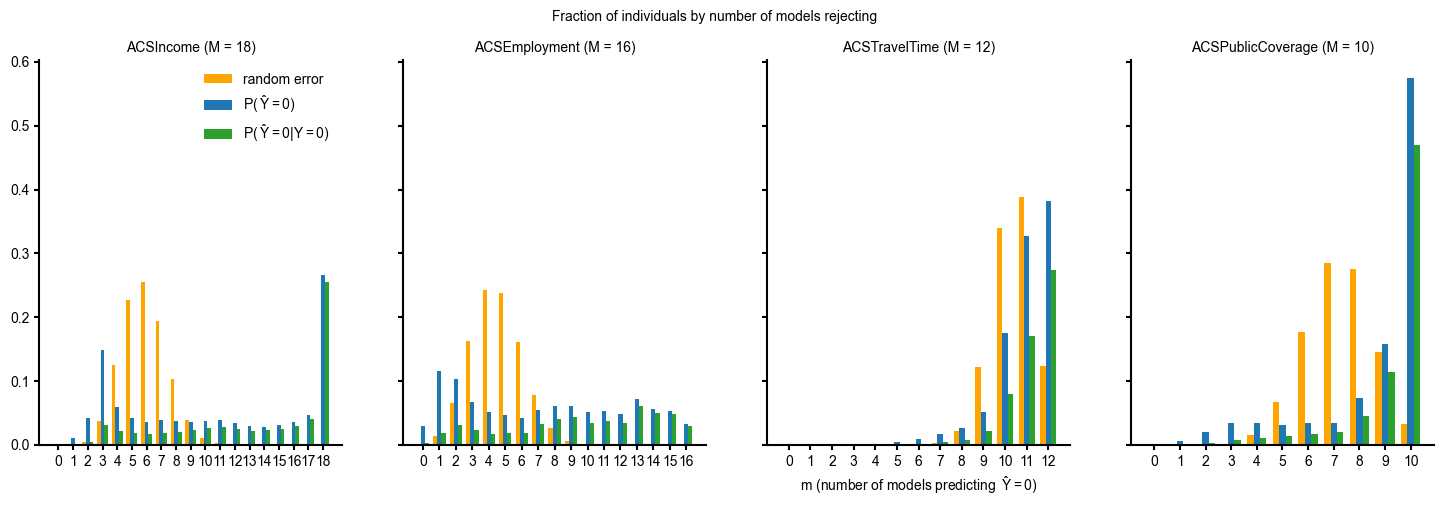

In [13]:
# Fraction of individuals by number of models rejecting
fig, axs = plt.subplots(1,len(ACS_TASKS), figsize=(18,5), sharey=True)
fig.suptitle('Fraction of individuals by number of models rejecting')
axs[2].set_xlabel("$m$ (number of models predicting $\hat{\,Y}=0$)")

for i, task in enumerate(ACS_TASKS):
    M = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {M})")

    # observed 
    values_all, counts_all = get_observed_rejections(predictions=predictions_above_baseline[task], restrict_only_pos_instances=False, true_labels=data[task][1])
    values_neg, counts_neg = get_observed_rejections(predictions=predictions_above_baseline[task], restrict_only_pos_instances=False, restrict_only_neg_instances=True, true_labels=data[task][1])
    num_samples = sum(counts_all)
        
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    fn_rates_filtered = [fn_rates[task][model] for model in models_above_baseline[task]]
    prob_expected = np.array([expected_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

    width=0.25
    axs[i].set_xticks(np.arange(M+1)+width, np.arange(M+1))
    axs[i].bar(np.arange(M+1), prob_expected, width=width, color='orange', label='random error')
    axs[i].bar(values_all+width, counts_all/num_samples, width=width, color='C0', label='$P(\hat{\,Y}=0)$')
    axs[i].bar(values_neg+2*width, counts_neg/num_samples, width=width, color='C2', label='$P(\hat{\,Y}=0|Y=0)$')
    

    if i==0:
        axs[i].legend()
plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_all_rejections.png')
plt.show()

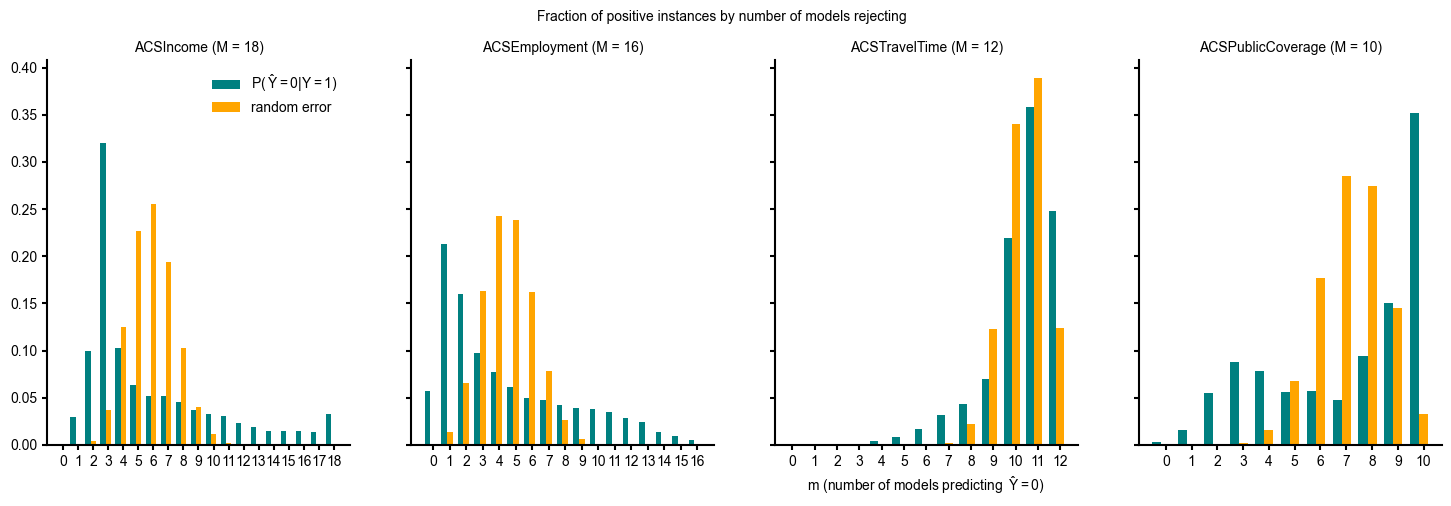

In [14]:
# Fraction of positive instances by number of models rejecting
fig, axs = plt.subplots(1,len(ACS_TASKS), figsize=(18,5), sharey=True)
fig.suptitle('Fraction of positive instances by number of models rejecting')
axs[2].set_xlabel("$m$ (number of models predicting $\hat{\,Y}=0$)")

for i, task in enumerate(ACS_TASKS):
    M = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {M})")

    # observed 
    values, counts = get_observed_rejections(predictions=predictions_above_baseline[task], restrict_only_pos_instances=True, true_labels=data[task][1])
    num_samples = sum(counts)
        
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    fn_rates_filtered = [fn_rates[task][model] for model in models_above_baseline[task]]
    prob_expected = np.array([expected_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

    width=0.35
    axs[i].set_xticks(np.arange(M+1)+width, np.arange(M+1))
    axs[i].bar(values, counts/num_samples, width=width, color='teal', label='$P(\hat{\,Y}=0|Y=1)$')
    axs[i].bar(np.arange(M+1)+width, prob_expected, width=width, color='orange', label='random error')

    if i==0:
        axs[i].legend()
plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_positives_rejections.png')
plt.show()

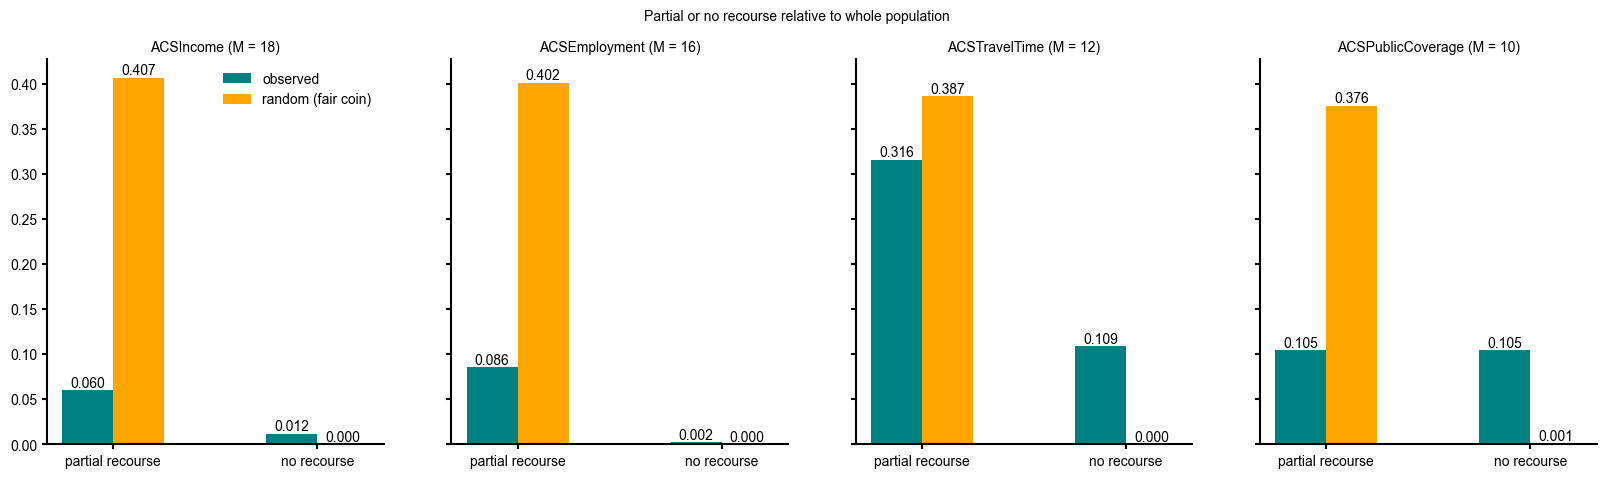

In [15]:
fig, axs = plt.subplots(1,len(ACS_TASKS), figsize=(20,5), sharey=True); fig.suptitle('Partial or no recourse relative to whole population')

for i, task in enumerate(ACS_TASKS):
    num_models = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {num_models})")

    num_models_rejected = num_models - predictions_above_baseline[task].sum(axis=1) #series: count of rejecting models
    
    y_test = data[task][1]
    indices_pos = y_test[y_test==1].index
    num_models_rejected_neg = num_models_rejected.loc[indices_pos] #filter: only positive instances
        
    prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    counts_rejected = np.array([len(num_models_rejected[num_models_rejected==i]) for i in range(0,num_models+1)])
    counts_rejects_neg = np.array([len(num_models_rejected_neg[num_models_rejected_neg==i]) for i in range(0,num_models+1)])

    partial_recourse = counts_rejects_neg[num_models//2+1:-1].sum()/y_test.shape[0]
    no_recourse = counts_rejects_neg[-1]/y_test.shape[0]

    width=0.25
    axs[i].set_xticks(np.arange(2)+0.5*width, [f'partial recourse', f'no recourse'])
    obs_bar = axs[i].bar(np.arange(2), [partial_recourse, no_recourse], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(2)+width, [prob_random[num_models//2+1:-1].sum(), prob_random[-1]], width=width, color='orange', label='random (fair coin)')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge')
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge')

    if i==0:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_to_whole_population.png')
plt.show()

### Recourse

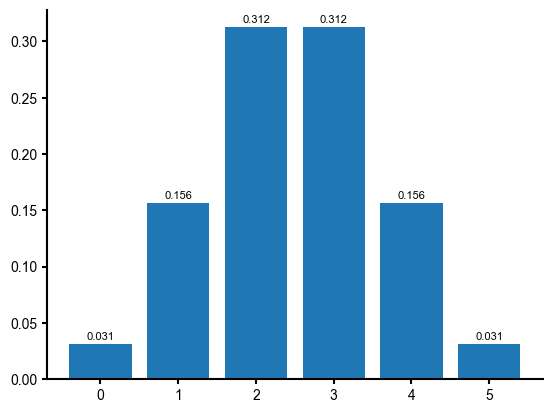

In [ ]:
def minimal_example_binomial(color_by_recourse=False):
    num = 5
    cut_off = (num+1)//2
    if color_by_recourse:
        colors = ['forestgreen'] + (cut_off-1)*['yellowgreen'] + (cut_off-1)*['orange'] + ['firebrick']
    else:
        colors = 'C0'
    probs = np.array([sp.special.binom(num, i) * 2**(-num) for i in range(0,num+1)])
    fig, ax = plt.subplots()
    bars = ax.bar(np.arange(num+1), probs, color=colors)
    ax.bar_label(bars, fmt='%.3f', label_type='edge', size=8, padding=2)
    ax.set_xticks(np.arange(num+1))
    # if color_by_recourse:
    #         # Create a Rectangle patch
    #         rect = patches.Rectangle((-0.5, -0.3), 1, 0.6, linewidth=1, edgecolor=colors[0], facecolor='none', zorder=5)
    #         # Add the patch to the Axes
    #         ax.add_patch(rect)
    plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_minimal_example.png')
    plt.show()
    probs[0], probs[:cut_off].sum(), probs[cut_off:-1].sum(), probs[-1]

    
minimal_example_binomial(color_by_recourse=True)

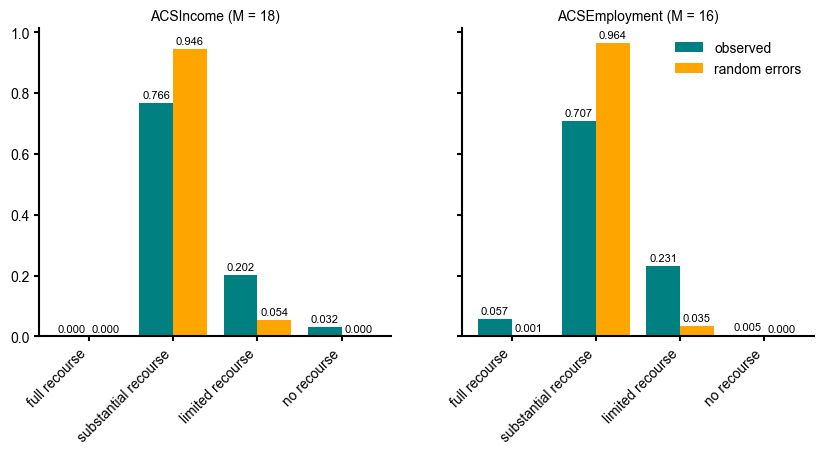

In [146]:
# Recourse among positive instances
tasks = ['ACSIncome', 'ACSEmployment'] #ACS_TASKS

fig, axs = plt.subplots(1,len(tasks), figsize=(10,4), sharey=True)
# fig.suptitle('Recourse among positive instances')

for i, task in enumerate(tasks):
    M = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {M})")

    # observed 
    values, counts = get_observed_rejections(predictions=predictions_above_baseline[task], restrict_only_pos_instances=True, true_labels=data[task][1])
    # pad counts with zeros to ensure correct slicing for recourse
    values_list = list(values)
    counts_padded = torch.tensor([counts[values_list.index(num)] if num in values_list else torch.tensor(0) for num in torch.arange(M+1)])
    num_samples = sum(counts)
        
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    fn_rates_filtered = [fn_rates[task][model] for model in models_above_baseline[task]]
    prob_expected = np.array([expected_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

    # recourse
    cut_off = (M+1)//2
    recourse = {'full': slice(1), 'substantial': slice(1,cut_off), 'limited': slice(cut_off, M), 'no': slice(M, M+1)}

    width=0.4
    axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
    obs_bar = axs[i].bar(np.arange(4), [counts_padded[s].sum()/num_samples for _,s in recourse.items()], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(4)+width, [prob_expected[s].sum() for _,s in recourse.items()], width=width, color='orange', label='random errors')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

    if i==len(tasks)-1:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse.png')
plt.show()



### Recourse By Model Family

In [148]:
model_families = ['gemma', 'llama', 'mistral', 'OLMo', 'Qwen', 'Yi']

ACSIncome
Gemma 2 9B (it)

ACSEmployment
Gemma 7B (it), Gemma 2 9B (it)



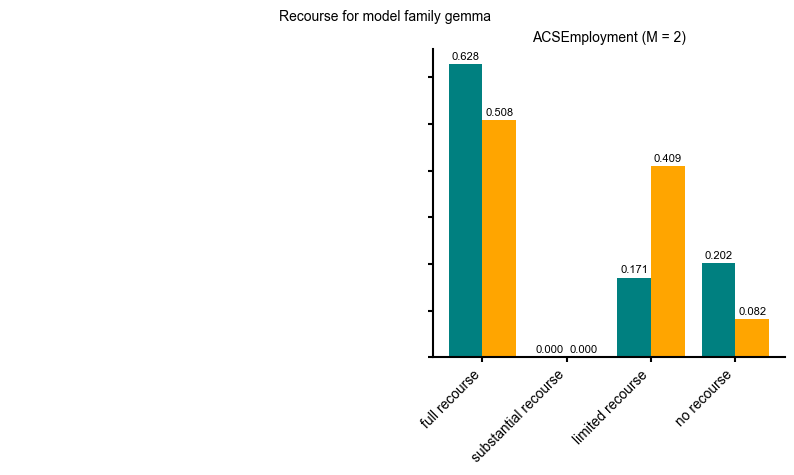

ACSIncome
Llama 3 70B, Meta Llama 3.1 70B, Meta Llama 3.1 70B (it), Llama 3 70B (it)

ACSEmployment
Meta Llama 3.2 1B (it), Meta Llama 3.2 3B (it), Llama 3 8B (it), Meta Llama 3.1 70B (it), Llama 3 70B (it)



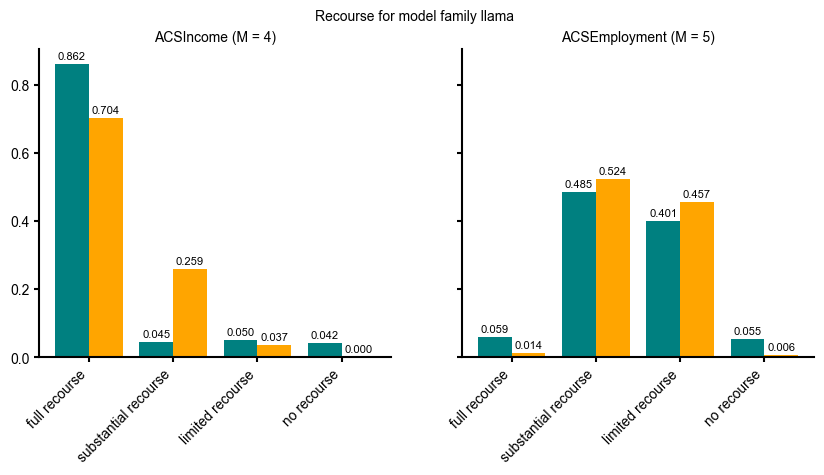

ACSIncome
Mistral 7B, Mistral 7B (it), Mixtral 8x7B, Mixtral 8x7B (it), Mixtral 8x22B, Mixtral 8x22B (it)

ACSEmployment
Mistral 7B (it), Mixtral 8x7B (it)



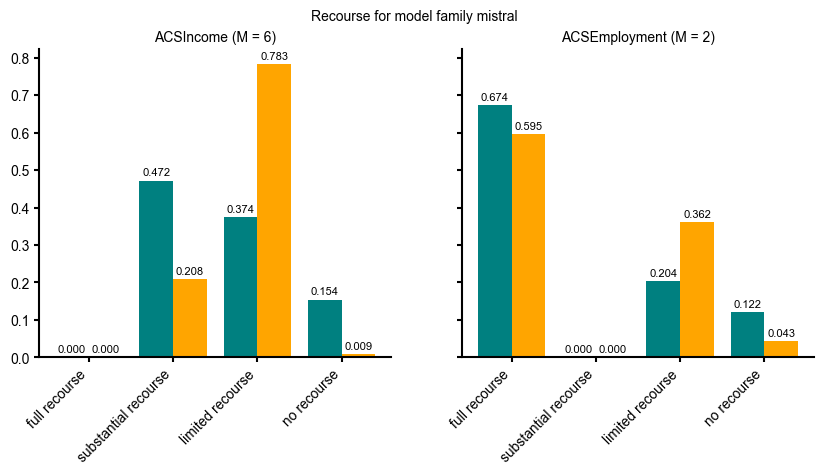

ACSIncome
OLMo 2 7B, OLMo 7B (it)

ACSEmployment
OLMo 2 7B (it)



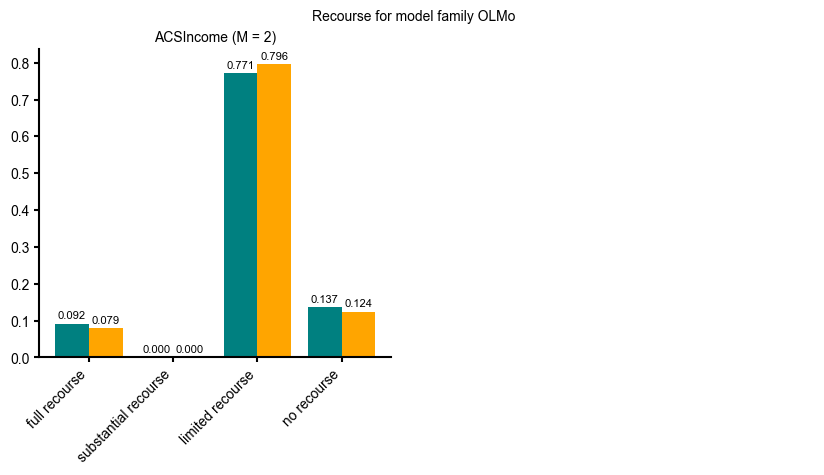

ACSIncome
Qwen 2 7B, Qwen 2 7B (it), Qwen 2 72B, Qwen 2 72B (it)

ACSEmployment
Qwen 2 7B, Qwen 2 7B (it), Qwen 2 72B



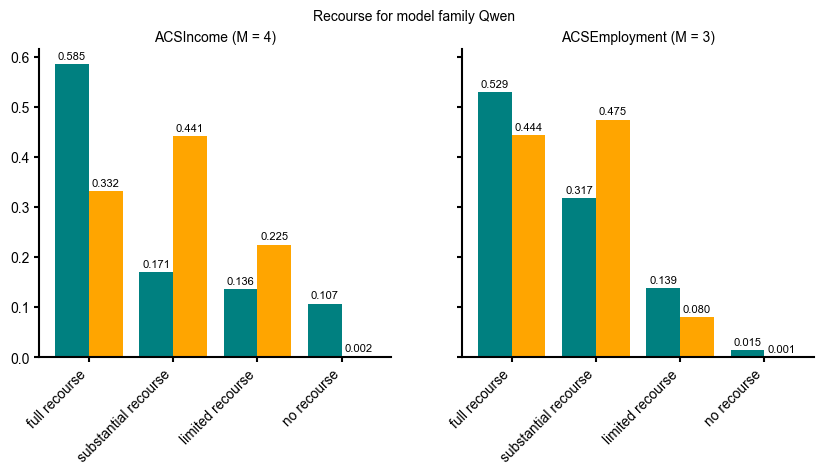

ACSIncome
Yi 34B (chat)

ACSEmployment
Yi 34B, Yi 34B (chat)



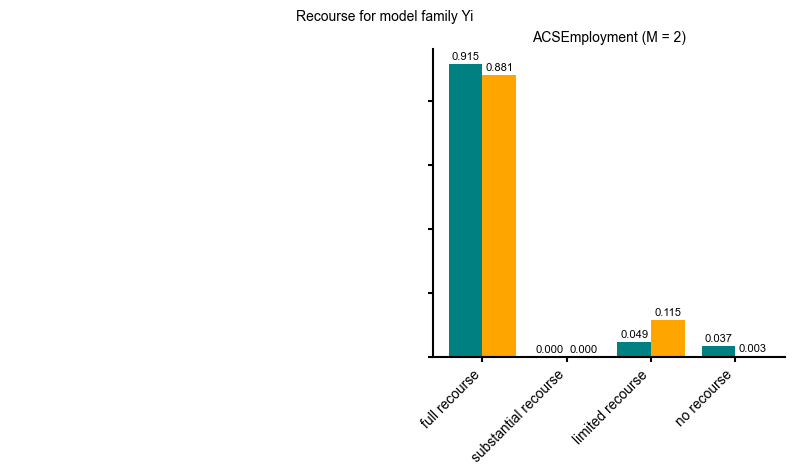

In [150]:
# Recourse for Model Family

for model_family in model_families:
    tasks = ['ACSIncome', 'ACSEmployment'] #ACS_TASKS
    fig, axs = plt.subplots(1,len(tasks), figsize=(10,4), sharey=True)
    fig.suptitle(f'Recourse for model family {model_family}')


    for i, task in enumerate(tasks):
        # filter predictions 
        predictions_model_family = predictions_above_baseline[task].filter(like=model_family)
        models = list(predictions_model_family.columns)
        print(f"{task}\n{', '.join([prettify_model_name(key_to_model(k)) for k in models])}\n")

        M = len(models)
        if M > 1: 
            axs[i].set_title(f"{task} (M = {M})")

            # observed 
            values, counts = get_observed_rejections(predictions=predictions_model_family, restrict_only_pos_instances=True, true_labels=data[task][1])
            # pad counts with zeros to ensure correct slicing for recourse
            values_list = list(values)
            counts_padded = torch.tensor([counts[values_list.index(num)] if num in values_list else torch.tensor(0) for num in torch.arange(M+1)])
            num_samples = sum(counts)
                
            # expected
            #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
            fn_rates_filtered = [fn_rates[task][model] for model in models]
            prob_expected = np.array([expected_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

            # recourse
            cut_off = (M+1)//2
            recourse = {'full': slice(1), 'substantial': slice(1,cut_off), 'limited': slice(cut_off, M), 'no': slice(M, M+1)}

            width=0.4
            axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
            obs_bar = axs[i].bar(np.arange(4), [counts_padded[s].sum()/num_samples for _,s in recourse.items()], width=width, color='teal', label='observed')
            rnd_bar = axs[i].bar(np.arange(4)+width, [prob_expected[s].sum() for _,s in recourse.items()], width=width, color='orange', label='random errors')
            axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
            axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

            if i==3:
                axs[i].legend()
        else: 
            axs[i].axis("off")

    plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_individual_recourse_family_{model_family}.png')
    plt.show()



### Recourse by top-k models

In [132]:
topk=10
sorted_models = sorted(accuracies[task].items(), key=lambda item: item[1], reverse=True)
sorted_models[:topk]

[('meta-llama--Meta-Llama-3-70B-Instruct', 0.7471206810215323),
 ('meta-llama--Meta-Llama-3.1-70B-Instruct', 0.7448892637201416),
 ('mistralai--Mixtral-8x7B-Instruct-v0.1', 0.7435451422748157),
 ('mistralai--Mixtral-8x22B-Instruct-v0.1', 0.7400925950329003),
 ('Qwen--Qwen2-72B-Instruct', 0.7329590877544386),
 ('01-ai--Yi-34B-Chat', 0.7225838758137206),
 ('mlfoundations--tabula-8b', 0.7220567693645732),
 ('meta-llama--Meta-Llama-3-8B-Instruct', 0.7068233929842132),
 ('meta-llama--Meta-Llama-3.1-8B-Instruct', 0.7053474949266004),
 ('01-ai--Yi-34B', 0.7027822435407497)]

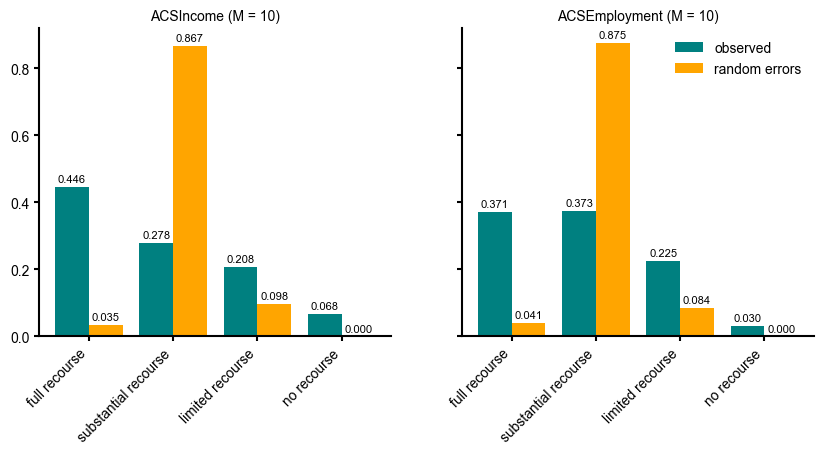

In [147]:
# Recourse top-k models
tasks = ['ACSIncome', 'ACSEmployment'] #ACS_TASKS
topk=10

fig, axs = plt.subplots(1,len(tasks), figsize=(10,4), sharey=True)
# fig.suptitle('Recourse among positive instances')

for i, task in enumerate(tasks):
    sorted_models = sorted(accuracies[task].items(), key=lambda item: item[1], reverse=True)
    models_topk = list(zip(*sorted_models[:topk]))[0]
    predictions_topk = predictions_above_baseline[task].filter(models_topk)
    M = topk
    axs[i].set_title(f"{task} (M = {M})")

    # observed 
    values, counts = get_observed_rejections(predictions=predictions_topk, restrict_only_pos_instances=True, true_labels=data[task][1])
    # pad counts with zeros to ensure correct slicing for recourse
    values_list = list(values)
    counts_padded = torch.tensor([counts[values_list.index(num)] if num in values_list else torch.tensor(0) for num in torch.arange(M+1)])
    num_samples = sum(counts)
        
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    fn_rates_filtered = [fn_rates[task][model] for model in models_topk]
    prob_expected = np.array([expected_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

    # recourse
    cut_off = (M+1)//2
    recourse = {'full': slice(1), 'substantial': slice(1,cut_off), 'limited': slice(cut_off, M), 'no': slice(M, M+1)}

    width=0.4
    axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
    obs_bar = axs[i].bar(np.arange(4), [counts_padded[s].sum()/num_samples for _,s in recourse.items()], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(4)+width, [prob_expected[s].sum() for _,s in recourse.items()], width=width, color='orange', label='random errors')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

    if i==len(tasks)-1:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_individual_recourse_top{topk}.png')
plt.show()



### Recourse base vs it

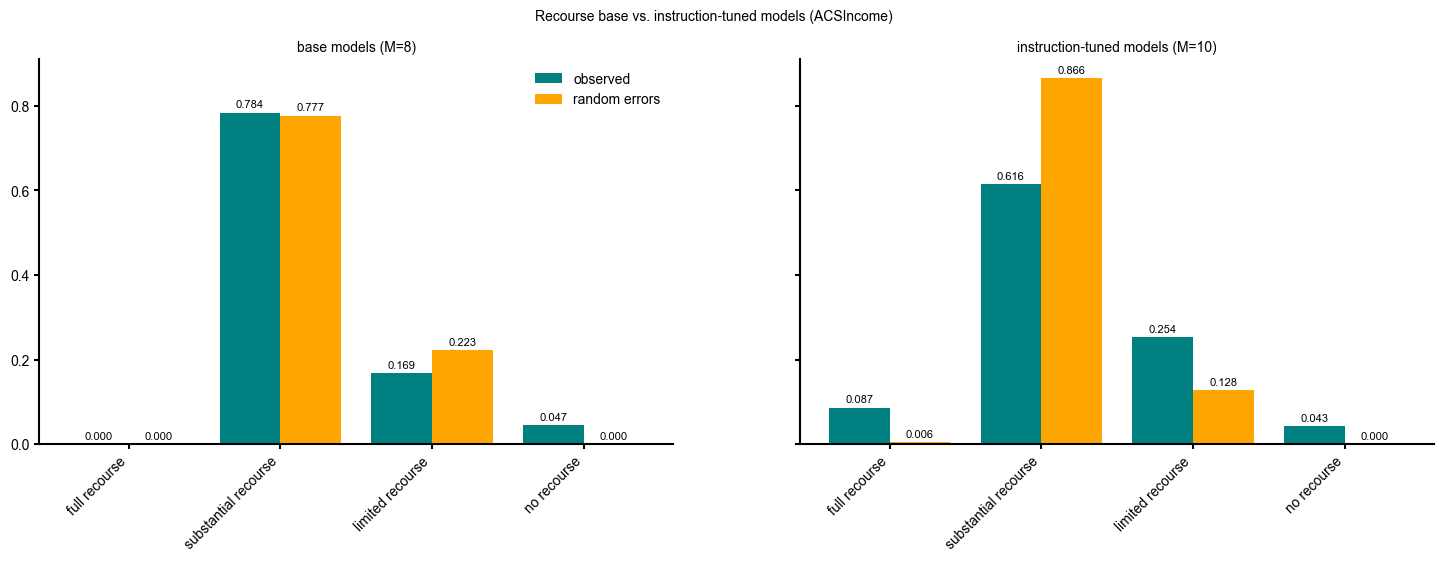

In [109]:
# Recourse base vs it
task = 'ACSIncome'
model_names_it = [m for m in predictions_above_baseline[task] if is_instruction_tuned(m) ]
model_names_base = [m for m in predictions_above_baseline[task] if not is_instruction_tuned(m) ]


fig, axs = plt.subplots(1,2, figsize=(18,5), sharey=True)
fig.suptitle('Recourse base vs. instruction-tuned models (ACSIncome)')

for i, models in enumerate([model_names_base, model_names_it]):
    M = len(models)
    # observed 
    values, counts = get_observed_rejections(predictions=predictions_above_baseline[task].filter(models), restrict_only_pos_instances=True, true_labels=data[task][1])    
    values_list = list(values)
    counts_padded = torch.tensor([counts[values_list.index(num)] if num in values_list else torch.tensor(0) for num in torch.arange(M+1)])
    num_samples = sum(counts)
    
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    fn_rates_filtered = [fn_rates[task][model] for model in models]
    prob_expected = np.array([expected_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,len(models)+1)])

    # recourse
    cut_off = (M+1)//2
    recourse = {'full': slice(1), 'substantial': slice(1,cut_off), 'limited': slice(cut_off, M), 'no': slice(M, M+1)}

    width=0.4
    axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
    obs_bar = axs[i].bar(np.arange(4), [counts_padded[s].sum()/num_samples for _,s in recourse.items()], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(4)+width, [prob_expected[s].sum() for _,s in recourse.items()], width=width, color='orange', label='random errors')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

    if i==0:
        axs[i].set_title(f"base models (M={M})")
        axs[i].legend()
    elif i ==1:
        axs[i].set_title(f"instruction-tuned models (M={M})")

plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_base_it.png')
plt.show()



### Recourse including classical/baseline models

In [57]:
baselines.keys()

dict_keys(['Constant', 'LR', 'GBM', 'XGBoost'])

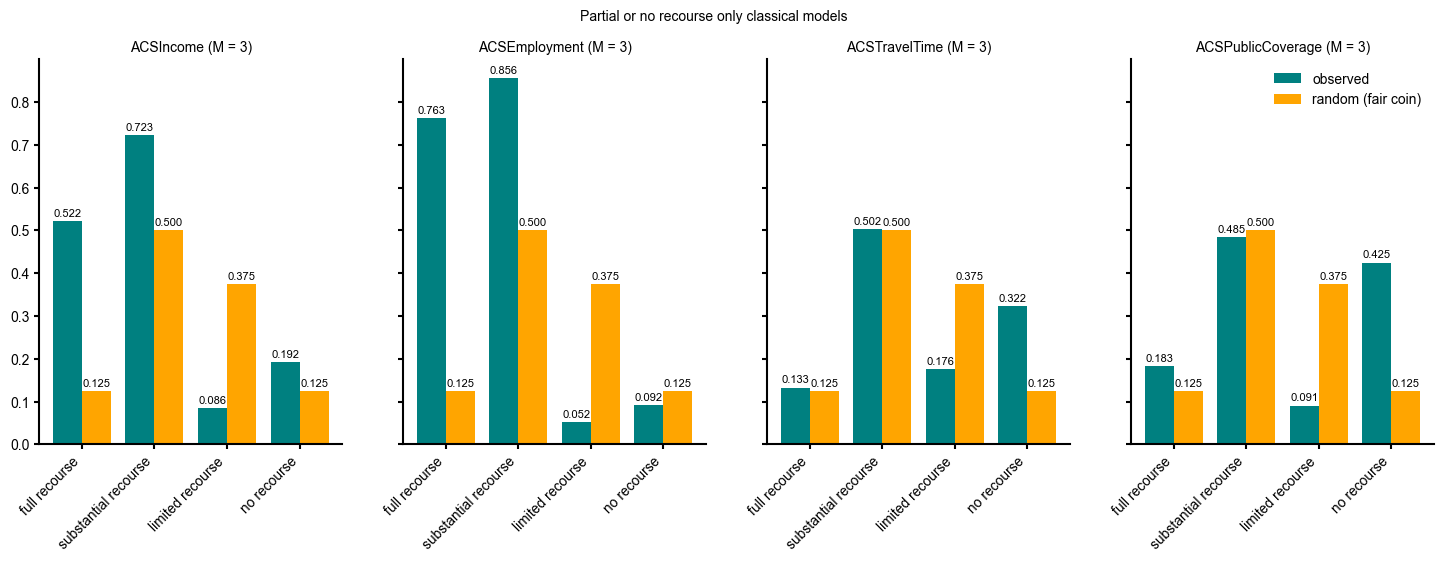

In [ ]:
fig, axs = plt.subplots(1,len(ACS_TASKS), figsize=(18,5), sharey=True); fig.suptitle('Partial or no recourse only classical models')

for i, task in enumerate(ACS_TASKS):
    num_models = 3
    axs[i].set_title(f"{task} (M = {num_models})")

    predictions_only_baselines = baseline_predictions[task].filter(items=[f'LR_task-{task}', f'GBM_task-{task}', f'XGBoost_task-{task}'])

    num_models_rejected = num_models - predictions_only_baselines.sum(axis=1) #series: count of rejecting models
    
    y_test = data[task][1]
    indices_pos = y_test[y_test==1].index
    num_models_rejected_neg = num_models_rejected.loc[indices_pos] #filter: only positive instances
        
    prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    counts_rejected = np.array([len(num_models_rejected[num_models_rejected==i]) for i in range(0,num_models+1)])
    counts_rejects_neg = np.array([len(num_models_rejected_neg[num_models_rejected_neg==i]) for i in range(0,num_models+1)])

    cut_off = (num_models+1)//2
    recourse = {'full' : counts_rejects_neg[0]/indices_pos.shape[0], # all models accept
                'partial' : counts_rejects_neg[:-1].sum()/indices_pos.shape[0], # some model accepts, but not all
                'substantial' : counts_rejects_neg[:cut_off].sum()/indices_pos.shape[0], # less than half rejects
                'limited' : counts_rejects_neg[cut_off:-1].sum()/indices_pos.shape[0], # at least half rejects, not all
                'no' : counts_rejects_neg[-1]/indices_pos.shape[0] # no model accepts
                }
    

    width=0.4
    axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
    obs_bar = axs[i].bar(np.arange(4), [recourse['full'], recourse['substantial'], recourse['limited'], recourse['no']], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(4)+width, [prob_random[0], prob_random[:cut_off].sum(), prob_random[cut_off:-1].sum(), prob_random[-1]], width=width, color='orange', label='random (fair coin)')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

    if i==3:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_only_classical.png')
plt.show()

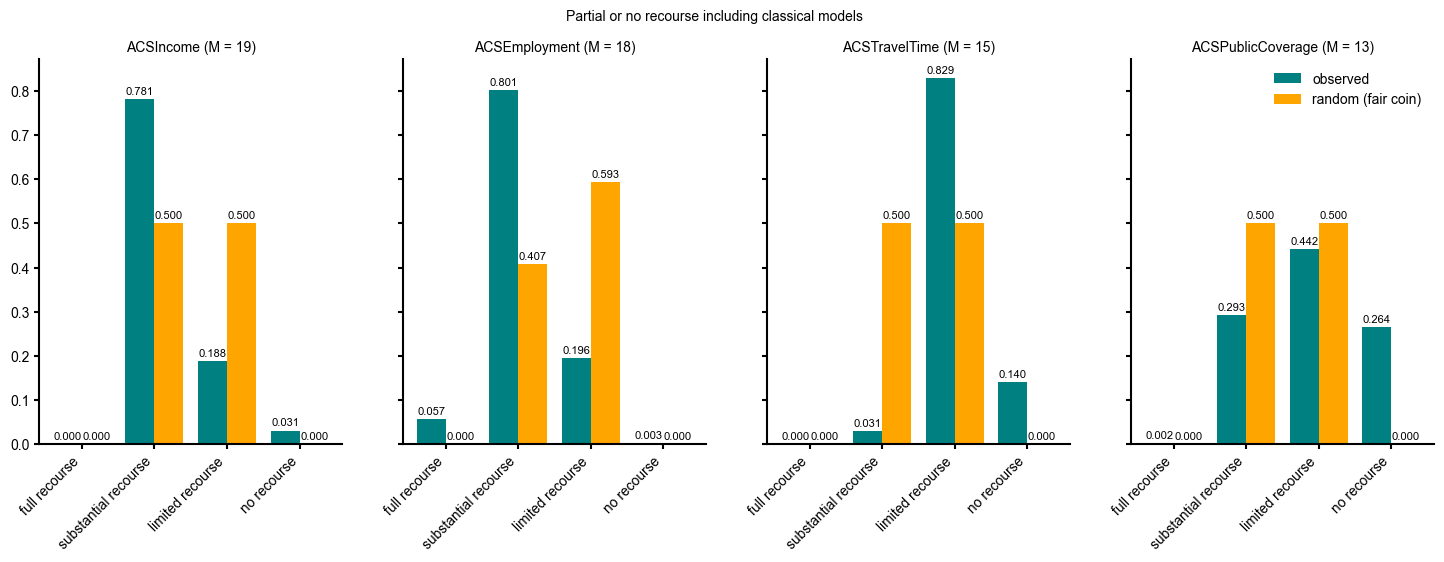

In [ ]:
fig, axs = plt.subplots(1,len(ACS_TASKS), figsize=(18,5), sharey=True); fig.suptitle('Partial or no recourse including classical models')

for i, task in enumerate(ACS_TASKS):
    num_models = len(models_above_baseline[task]) + 3
    axs[i].set_title(f"{task} (M = {num_models})")

    predictions_with_baselines = pd.concat([baseline_predictions[task].filter(items=[f'LR_task-{task}', f'GBM_task-{task}', f'XGBoost_task-{task}']), predictions_above_baseline[task]], axis=1) #todo: only if baseline is better than constant

    num_models_rejected = num_models - predictions_with_baselines.sum(axis=1) #series: count of rejecting models
    
    y_test = data[task][1]
    indices_pos = y_test[y_test==1].index
    num_models_rejected_neg = num_models_rejected.loc[indices_pos] #filter: only positive instances
        
    prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    counts_rejected = np.array([len(num_models_rejected[num_models_rejected==i]) for i in range(0,num_models+1)])
    counts_rejects_neg = np.array([len(num_models_rejected_neg[num_models_rejected_neg==i]) for i in range(0,num_models+1)])

    cut_off = (num_models+1)//2
    recourse = {'full' : counts_rejects_neg[0]/indices_pos.shape[0], # all models accept
                'partial' : counts_rejects_neg[:-1].sum()/indices_pos.shape[0], # some model accepts, but not all
                'substantial' : counts_rejects_neg[:cut_off].sum()/indices_pos.shape[0], # less than half rejects
                'limited' : counts_rejects_neg[cut_off:-1].sum()/indices_pos.shape[0], # at least half rejects, not all
                'no' : counts_rejects_neg[-1]/indices_pos.shape[0] # no model accepts
                }
    

    width=0.4
    axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
    obs_bar = axs[i].bar(np.arange(4), [recourse['full'], recourse['substantial'], recourse['limited'], recourse['no']], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(4)+width, [prob_random[0], prob_random[:cut_off].sum(), prob_random[cut_off:-1].sum(), prob_random[-1]], width=width, color='orange', label='random (fair coin)')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

    if i==3:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_incl_classical.png')
plt.show()